# Air Quality Prediction Using Machine Learning

## 1. Problem Definition

Air pollution is an important environmental and public health problem. Monitoring air quality helps us understand pollution levels and take appropriate actions.

In this project, we will use historical air-quality and environmental measurements to train a machine learning model that can predict the concentration of a selected air pollutant.

We will use supervised machine learning and the XGBoost algorithm to build a regression model. The model will learn relationships between different air-quality measurements and the target pollutant concentration.


## 2. Importing Required Libraries

We import the Python libraries needed for data analysis, visualization, preprocessing, machine learning, and model evaluation.

In [39]:
# Handles and analyzes the dataset
import pandas as pd

# Performs numerical calculations
import numpy as np

# Creates graphs and visualizations
import matplotlib.pyplot as plt

# Calculates model performance metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Provides the XGBoost regression algorithm
from xgboost import XGBRegressor

## 3. Loading the Dataset

In this step, we load the Air Quality dataset from the UCI Machine Learning Repository into a pandas DataFrame for analysis and machine learning.

### Dataset Source

Vito, S. (2008). *Air Quality* [Dataset]. UCI Machine Learning Repository.

DOI: https://doi.org/10.24432/C59K5F

In [21]:
df = pd.read_csv("/content/AirQualityUCI.csv", sep=";", decimal=",", encoding="latin1")

df.head()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578,NaN,NaN
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255,NaN,NaN
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,NaN,NaN
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867,NaN,NaN
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888,NaN,NaN


## 4. Understanding the Dataset

Before building our machine learning model, we need to understand the structure of the dataset.

We will check:
- The number of rows and columns
- The column names
- The data types
- Basic information about the dataset
- Summary statistics

In [22]:
# Check the size of the dataset
print("Dataset shape:", df.shape)

# Display the column names
print("\nColumn names:")
print(df.columns.tolist())

# Display information about the dataset
print("\nDataset information:")
df.info()

Dataset shape: (9471, 17)

Column names:
['Date', 'Time', 'CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH', 'Unnamed: 15', 'Unnamed: 16']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9471 entries, 0 to 9470
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           9357 non-null   object 
 1   Time           9357 non-null   object 
 2   CO(GT)         9357 non-null   float64
 3   PT08.S1(CO)    9357 non-null   float64
 4   NMHC(GT)       9357 non-null   float64
 5   C6H6(GT)       9357 non-null   float64
 6   PT08.S2(NMHC)  9357 non-null   float64
 7   NOx(GT)        9357 non-null   float64
 8   PT08.S3(NOx)   9357 non-null   float64
 9   NO2(GT)        9357 non-null   float64
 10  PT08.S4(NO2)   9357 non-null   float64
 11  PT08.S5(O3)    9357 non-null   float64
 12  T         

## 5. Cleaning the Dataset

The original dataset contains empty columns and missing values. Before training the machine learning model, we need to clean these issues.

In this step, we will:
- Remove completely empty columns
- Remove completely empty rows
- Replace the value -200 with missing values (NaN)
- Check how many missing values remain

In [23]:
# Remove columns that contain no data
df = df.dropna(axis=1, how="all")

# Remove rows that contain no data
df = df.dropna(axis=0, how="all")

# Replace -200 with NaN because -200 represents missing measurements
df = df.replace(-200, np.nan)

# Check the number of missing values in each column
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
Date                0
Time                0
CO(GT)           1683
PT08.S1(CO)       366
NMHC(GT)         8443
C6H6(GT)          366
PT08.S2(NMHC)     366
NOx(GT)          1639
PT08.S3(NOx)      366
NO2(GT)          1642
PT08.S4(NO2)      366
PT08.S5(O3)       366
T                 366
RH                366
AH                366
dtype: int64


## 6. Handling Missing Values

Some measurements in the dataset are missing. We will handle these missing values before training the machine learning model.

Columns with a very large number of missing values can make the model less reliable, so we will remove columns with excessive missing data.

For the remaining columns, we will fill missing numerical values using the median of each column.

In [24]:
# Remove the NMHC(GT) column because it contains too many missing values
df = df.drop(columns=["NMHC(GT)"])

# Fill missing numerical values with the median of each column
numeric_columns = df.select_dtypes(include=np.number).columns
df[numeric_columns] = df[numeric_columns].fillna(df[numeric_columns].median())

# Check if any missing values remain
print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
Date             0
Time             0
CO(GT)           0
PT08.S1(CO)      0
C6H6(GT)         0
PT08.S2(NMHC)    0
NOx(GT)          0
PT08.S3(NOx)     0
NO2(GT)          0
PT08.S4(NO2)     0
PT08.S5(O3)      0
T                0
RH               0
AH               0
dtype: int64


## 7. Defining the Target and Features

In this project, we will predict the concentration of carbon monoxide (CO).

The target variable is `CO(GT)`, which represents the measured carbon monoxide concentration.

The other numerical air-quality and environmental measurements will be used as features to help the model predict the CO concentration.

The `Date` and `Time` columns are excluded because they are stored as text and will not be used directly as model inputs.

In [25]:
# Define the target variable
y = df["CO(GT)"]

# Define the input features
X = df.drop(columns=["CO(GT)", "Date", "Time"])

# Display the shapes
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (9357, 11)
y shape: (9357,)


## 8. Splitting the Dataset

The dataset contains air-quality measurements recorded over time.

To evaluate our model fairly, we will divide the data into two parts:

- 80% of the data will be used to train the model.
- 20% of the data will be used to test the model.

Because the data is time-based, we will keep the chronological order instead of randomly shuffling the observations. This allows us to simulate predicting future air-quality measurements using historical data.

In [26]:
# Calculate the point where we split the data
split_index = int(len(X) * 0.8)

# Split the data chronologically
X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

# Display the sizes
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (7485, 11)
Testing data: (1872, 11)


## 9. Comparing Regression Models

Since this is a regression project, we will compare different regression algorithms to determine which model performs best for predicting CO concentration.

We will compare four models:

- Linear Regression
- Random Forest Regressor
- Gradient Boosting Regressor
- XGBoost Regressor

All four models will be trained using the same training data and evaluated using the same test data.

We will compare their performance using:
- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

The model with the best overall performance will be selected for the final project and deployment.

In [27]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Create the four regression models and train them side by side

linear_model = LinearRegression()

random_forest_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

gradient_boosting_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

xgboost_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# Train each model using the same training data

linear_model.fit(X_train, y_train)

random_forest_model.fit(X_train, y_train)

gradient_boosting_model.fit(X_train, y_train)

xgboost_model.fit(X_train, y_train)

print("All four regression models trained successfully!")

All four regression models trained successfully!


In [28]:
# Make predictions on the same test data

linear_pred = linear_model.predict(X_test)

random_forest_pred = random_forest_model.predict(X_test)

gradient_boosting_pred = gradient_boosting_model.predict(X_test)

xgboost_pred = xgboost_model.predict(X_test)

print("Predictions completed successfully!")

Predictions completed successfully!


In [29]:
# Calculate evaluation metrics for each model

results = []

models_and_predictions = [
    ("Linear Regression", linear_pred),
    ("Random Forest", random_forest_pred),
    ("Gradient Boosting", gradient_boosting_pred),
    ("XGBoost", xgboost_pred)
]

for name, predictions in models_and_predictions:
    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R² Score": r2
    })

# Create a comparison table
comparison_df = pd.DataFrame(results)

print("Model Comparison Results:")
print(comparison_df)

Model Comparison Results:
               Model       MAE      RMSE  R² Score
0  Linear Regression  0.497008  0.690554  0.734540
1      Random Forest  0.467396  0.671544  0.748955
2  Gradient Boosting  0.501380  0.677912  0.744170
3            XGBoost  0.469990  0.666690  0.752571


## We experimentally compared four regression models, and XGBoost achieved the best overall performance, so we selected XGBoost as the final model for deployment.

## 10. Selecting the Best Model

After comparing four regression models, we selected XGBoost as the final model.

XGBoost achieved the highest R² Score of 0.7526 and the lowest RMSE of 0.6667 among the four models. Its MAE was 0.4700, which was also very close to the Random Forest model's MAE of 0.4674.

Based on the overall results, XGBoost provided the best performance for our CO concentration prediction task.

Therefore, XGBoost will be used as the final model for visualization, saving, and deployment.

In [30]:
# Select XGBoost as the final model
model = xgboost_model

print("Final model selected: XGBoost Regressor")

Final model selected: XGBoost Regressor


## 11. Evaluating the Final Model

Now that XGBoost has been selected as our final model, we will evaluate its performance on the test data.

We will use three evaluation metrics:

- **Mean Absolute Error (MAE):** Measures the average difference between the actual and predicted CO values.
- **Root Mean Squared Error (RMSE):** Measures prediction error while giving more weight to larger errors.
- **R² Score:** Shows how well the model explains the variation in the target CO concentration.

These metrics will help us determine how well our final model performs on unseen data.

In [32]:
# Make predictions using the final XGBoost model
y_pred = model.predict(X_test)

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

# Display the results
print("Final XGBoost Model Performance")
print("--------------------------------")
print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

Final XGBoost Model Performance
--------------------------------
MAE: 0.4699897884558409
RMSE: 0.6666897264288205
R² Score: 0.7525707494143955


## 12. Making Predictions (Let's Check How Good The Model Is)

After training the XGBoost model, we use it to make predictions on the test dataset.

The test data was not used during training, so it allows us to see how well the model can predict CO concentrations for previously unseen measurements.

In [33]:
# Make predictions using the test data
y_pred = model.predict(X_test)

# Display the first 10 predictions
print("First 10 predicted CO concentrations:")
print(y_pred[:10])

First 10 predicted CO concentrations:
[0.96024567 1.3456589  1.5614617  1.546395   1.742671   2.1812277
 1.6232991  1.3322281  1.5611714  1.3619874 ]


## 13. Evaluating the Model

After making predictions, we need to evaluate how well the model performs on unseen test data.

We will use three evaluation metrics:

- Mean Absolute Error (MAE): Measures the average difference between the predicted and actual CO concentrations.
- Root Mean Squared Error (RMSE): Measures prediction error while giving more weight to larger errors.
- R² Score: Measures how well the model explains the variation in the target variable.

These metrics will help us determine the performance of our XGBoost regression model.

In [34]:
# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

# Display the results
print("Model Evaluation Results")
print("------------------------")
print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

Model Evaluation Results
------------------------
MAE: 0.4699897884558409
RMSE: 0.6666897264288205
R² Score: 0.7525707494143955


## 14. Visualizing Actual vs Predicted Values

We will compare the actual CO concentrations with the values predicted by our XGBoost model using a scatter plot.

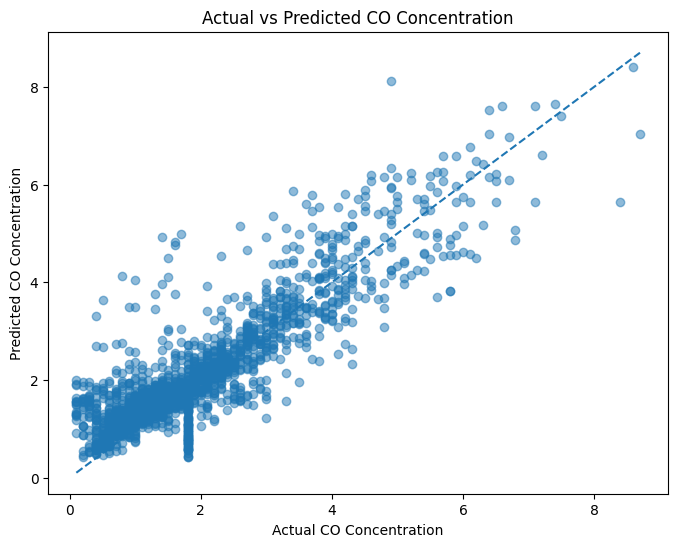

In [35]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual CO Concentration")
plt.ylabel("Predicted CO Concentration")
plt.title("Actual vs Predicted CO Concentration")
plt.show()

## 15. Feature Importance

XGBoost can show us which input features were most important when making predictions.

This helps us understand which air-quality and environmental measurements contributed most to predicting CO concentration.

          Feature  Importance
1        C6H6(GT)    0.341474
2   PT08.S2(NMHC)    0.324385
3         NOx(GT)    0.146108
5         NO2(GT)    0.066766
0     PT08.S1(CO)    0.043690
8               T    0.016696
4    PT08.S3(NOx)    0.013267
6    PT08.S4(NO2)    0.012798
9              RH    0.012648
7     PT08.S5(O3)    0.012187
10             AH    0.009980


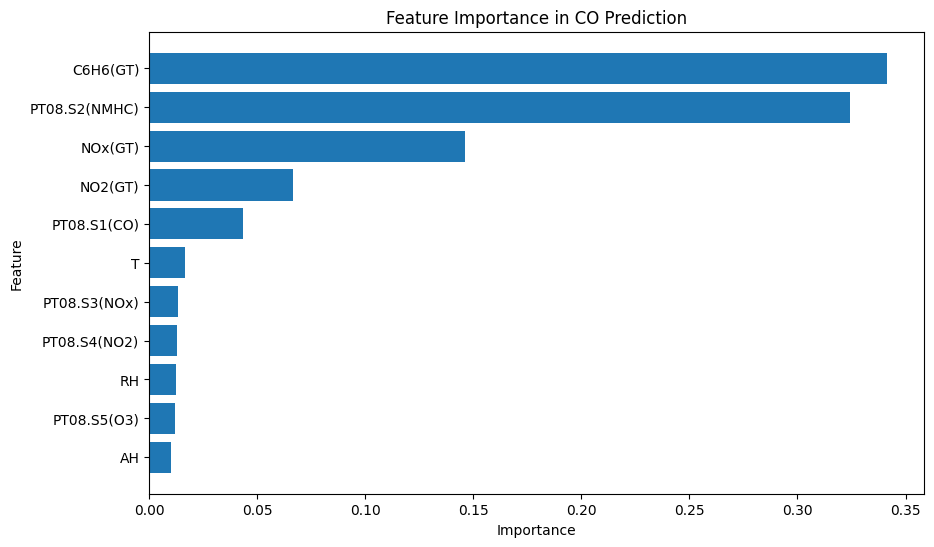

In [36]:
# Get feature importance from the trained model
importance = model.feature_importances_

# Create a DataFrame for easier viewing
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

# Sort features from most important to least important
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Display the feature importance
print(feature_importance)

# Plot the feature importance
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance in CO Prediction")
plt.gca().invert_yaxis()

plt.show()

## 16. Saving the Trained Model

The trained XGBoost model needs to be saved so that we can use it later during deployment.

Instead of training the model every time a user wants a prediction, the deployed application will load this saved model and use it to predict CO concentration from new input measurements.

In [37]:
import joblib

# Save the trained model
joblib.dump(model, "air_quality_xgboost_model.pkl")

print("Model saved successfully!")

Model saved successfully!


## 17. Testing the Model with New Input

Before deployment, we will test the saved model using a new set of air-quality measurements.

This simulates what will happen when a user enters measurements into our future web application. The model will use these values to predict the CO concentration.

In [38]:
# Load the saved model
loaded_model = joblib.load("air_quality_xgboost_model.pkl")

# Create a sample set of new measurements
sample_input = pd.DataFrame([{
    "PT08.S1(CO)": 1000,
    "C6H6(GT)": 10,
    "PT08.S2(NMHC)": 900,
    "NOx(GT)": 150,
    "PT08.S3(NOx)": 800,
    "NO2(GT)": 100,
    "PT08.S4(NO2)": 1200,
    "PT08.S5(O3)": 1000,
    "T": 20,
    "RH": 50,
    "AH": 1.0
}])

# Make a prediction
prediction = loaded_model.predict(sample_input)

print("Predicted CO concentration:", prediction[0])

Predicted CO concentration: 1.8172414
